# Results Parser

In [2]:
import pandas
import matplotlib.pyplot as plt

## Collating all stages results into 1 table

In [15]:
FILE_PREFIX = "hmm-em-xpos"
NUM_STAGES = 25

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./results/{FILE_PREFIX}/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./results/{FILE_PREFIX}/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 13 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,8.441345,0.875019,0.138878,0.113611,0.124981,1
0,0,-,8.376469,0.873674,0.139509,0.115420,0.126326,2
0,0,-,8.184481,0.872826,0.137360,0.118395,0.127174,3
0,0,-,7.783796,0.871892,0.131735,0.124675,0.128108,4
0,0,-,7.343867,0.871093,0.125179,0.132863,0.128907,5


## Load actual full dataset stats

In [27]:
FILE_PREFIX = "hmm-sem-upos"

whole_dataset_results = pandas.read_csv(f"./results/{FILE_PREFIX}/{FILE_PREFIX}.csv")
display(whole_dataset_results)

,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score
0,0,-,3.979159,0.533721,0.491827,0.443254,0.466279


## Dirichlet Initialisation with alpha 0.5

## HMM Hard EM BOTH TAGS DIR

In [ ]:
import pandas
import matplotlib.pyplot as plt

TAG = "upos"
FILE_PREFIX = f"hmm-hard-em-{TAG}-dir"
NUM_STAGES = 50

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 31 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,6.471396,0.914063,0.086078,0.085797,0.085937,1
0,0,-,6.466967,0.913454,0.086686,0.086406,0.086546,2
0,0,-,6.463818,0.912986,0.087157,0.086871,0.087014,3
0,0,-,6.460428,0.912506,0.087638,0.087351,0.087494,4
0,0,-,6.457355,0.912008,0.088143,0.087841,0.087992,5


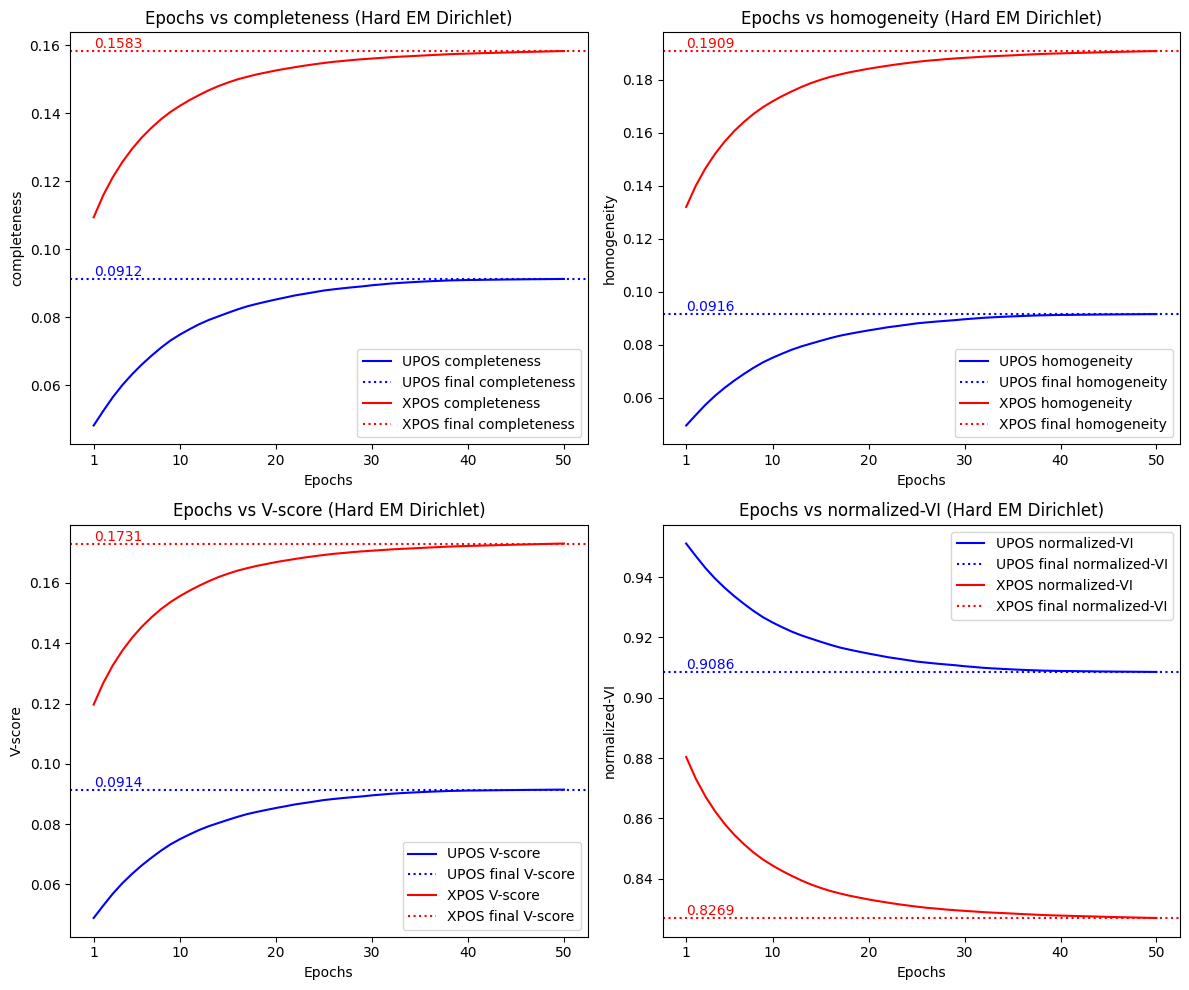

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


FILE_PREFIXES = ["hmm-hard-em-upos-dir", "hmm-hard-em-xpos-dir"]
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]
LABELS = ["UPOS", "XPOS"]
COLORS = ["b", "r"]  # one color for each result type
FINAL_LINE_COLORS = ["b", "r"]

# Load both results
all_results = []
for FILE_PREFIX in FILE_PREFIXES:
    results = pd.read_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")
    all_results.append(results)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):
    ax = axes[i]
    for idx, results in enumerate(all_results):
        label = LABELS[idx]
        color = COLORS[idx]
        final_color = FINAL_LINE_COLORS[idx]

        epochs = results["epoch"]

        ax.plot(epochs, results[FIELD], label=f"{label} {FIELD}", color=color)

        # Add horizontal line for the last epoch's value
        last_value = results[FIELD].iloc[-1]
        ax.axhline(
            y=last_value,
            color=final_color,
            linestyle=':',
            label=f'{label} final {FIELD}'
        )
        
        # Add the value label near the left
        ax.text(
            epochs.min(), last_value, 
            f"{last_value:.4f}", 
            va='bottom', ha='left', color=final_color
        )
    
    ax.set_xticks([1, 10, 20, 30, 40, 50])

    ax.set_title(f"Epochs vs {FIELD} (Hard EM Dirichlet)")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()
    ax.legend()
plt.tight_layout()

## HMM Hard EM PER TAG DIR

In [ ]:
TAG = "xpos"
FILE_PREFIX = f"hmm-hard-em-{TAG}-dir"
NUM_STAGES = 50

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

: 

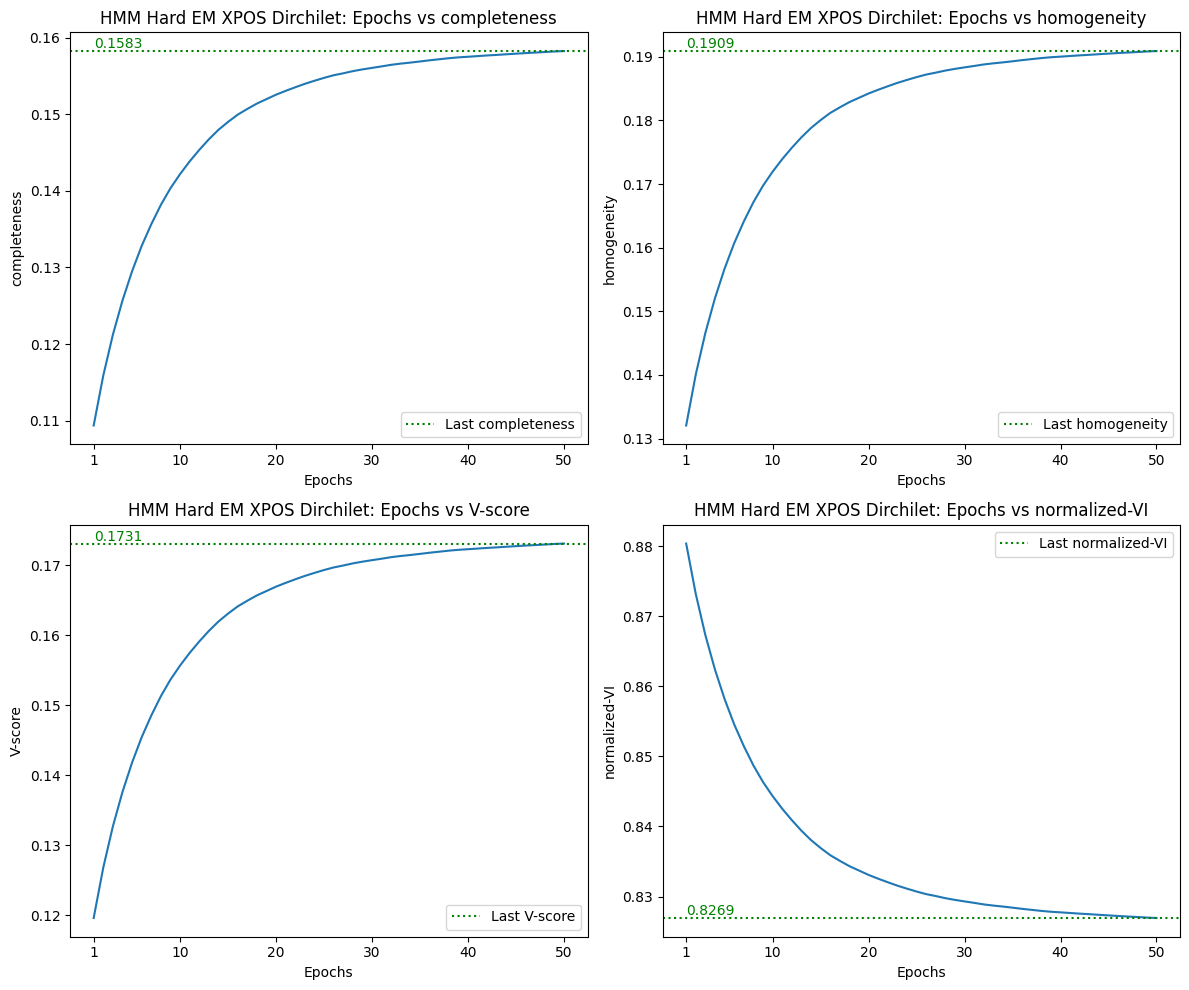

In [58]:
import pandas as pd 
import matplotlib.pyplot as plt

TAG = "xpos"
FILE_PREFIX = f"hmm-hard-em-{TAG}-dir"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pd.read_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"][[0, 9, 19, 29, 39, 49]])

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM Hard EM {TAG.upper()} Dirchilet: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## HMM sEM BOTH TAGS DIR

In [ ]:
TAG = "upos"
FILE_PREFIX = f"hmm-sem-{TAG}-dir"
NUM_STAGES = 50

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 21 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,4.004244,0.540163,0.482269,0.439400,0.459837,1
0,0,-,3.977847,0.535685,0.487799,0.442989,0.464315,2
0,0,-,3.895520,0.525102,0.498439,0.453481,0.474898,3
0,0,-,3.921063,0.528369,0.495174,0.450225,0.471631,4
0,0,-,3.885473,0.523261,0.500837,0.454854,0.476739,5


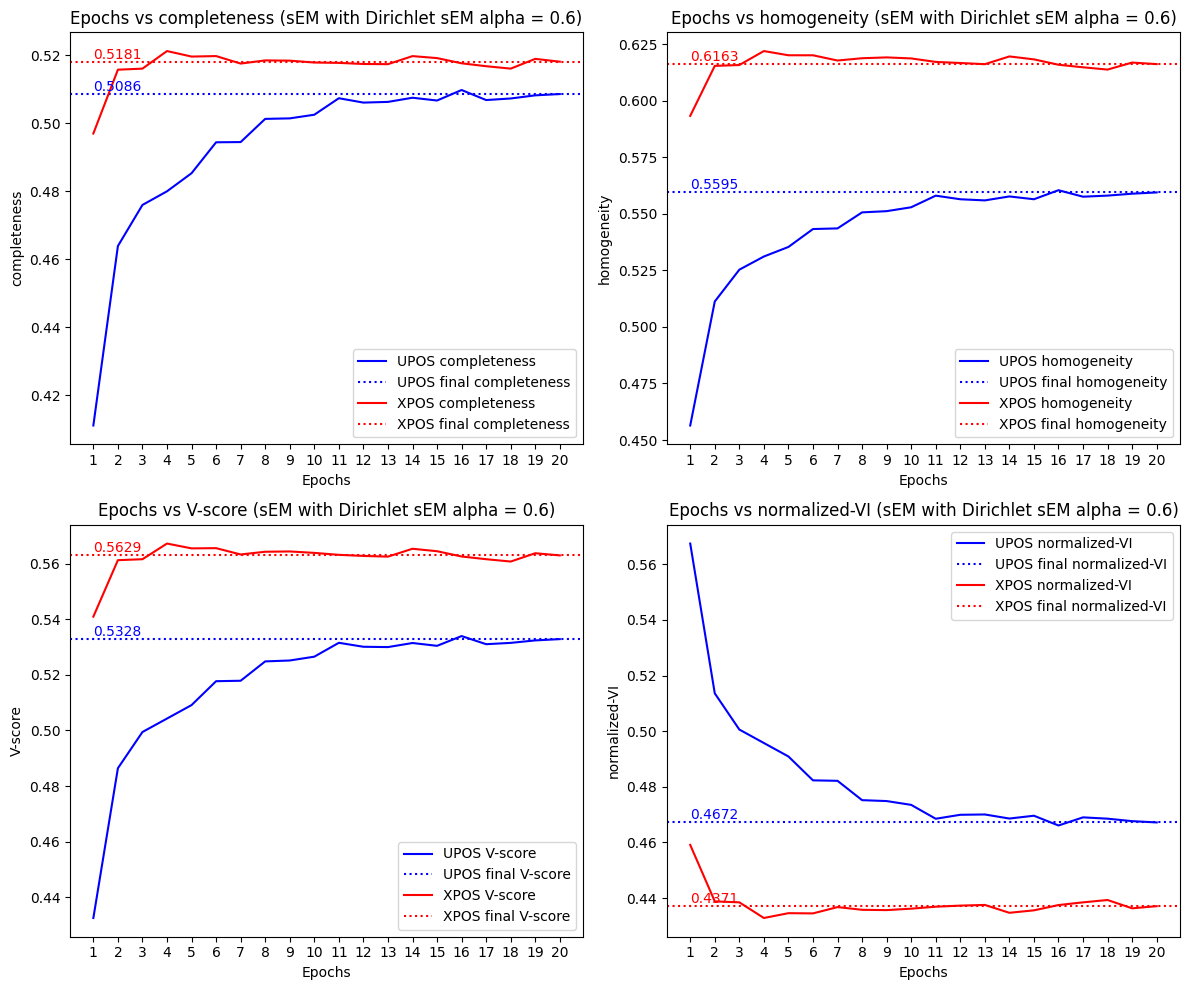

In [37]:
import pandas as pd
import matplotlib.pyplot as plt


FILE_PREFIXES = ["hmm-sem-upos-dir-alpha-0.6", "hmm-sem-xpos-dir-alpha-0.6"]
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]
NUM_STAGES = 20

LABELS = ["UPOS", "XPOS"]
COLORS = ["b", "r"]  # one color for each result type
FINAL_LINE_COLORS = ["b", "r"]

# Load both results
all_results = []
for FILE_PREFIX in FILE_PREFIXES:
    results = pd.read_csv(f"./output_old_sem_batch_size/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")
    all_results.append(results)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):
    ax = axes[i]
    for idx, results in enumerate(all_results):
        label = LABELS[idx]
        color = COLORS[idx]
        final_color = FINAL_LINE_COLORS[idx]

        epochs = results["epoch"]

        ax.plot(epochs, results[FIELD], label=f"{label} {FIELD}", color=color)

        # Add horizontal line for the last epoch's value
        last_value = results[FIELD].iloc[-1]
        ax.axhline(
            y=last_value,
            color=final_color,
            linestyle=':',
            label=f'{label} final {FIELD}'
        )
        
        # Add the value label near the left
        ax.text(
            epochs.min(), last_value, 
            f"{last_value:.4f}", 
            va='bottom', ha='left', color=final_color
        )
    
    ax.set_xticks(range(1, NUM_STAGES + 1))

    ax.set_title(f"Epochs vs {FIELD} (sEM with Dirichlet sEM alpha = 0.6)")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## HMM sEM PER TAG DIR

In [ ]:
import pandas
import matplotlib.pyplot as plt

TAG = "upos"
FILE_PREFIX = f"hmm-sem-{TAG}-dir"
NUM_STAGES = 20

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 21 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,4.247274,0.472116,0.547014,0.510048,0.527884,1
0,0,-,4.237791,0.463610,0.564761,0.510733,0.536390,2
0,0,-,4.284882,0.472799,0.550346,0.505924,0.527201,3
0,0,-,4.272699,0.470851,0.553087,0.507197,0.529149,4
0,0,-,4.294934,0.474826,0.547171,0.504878,0.525174,5


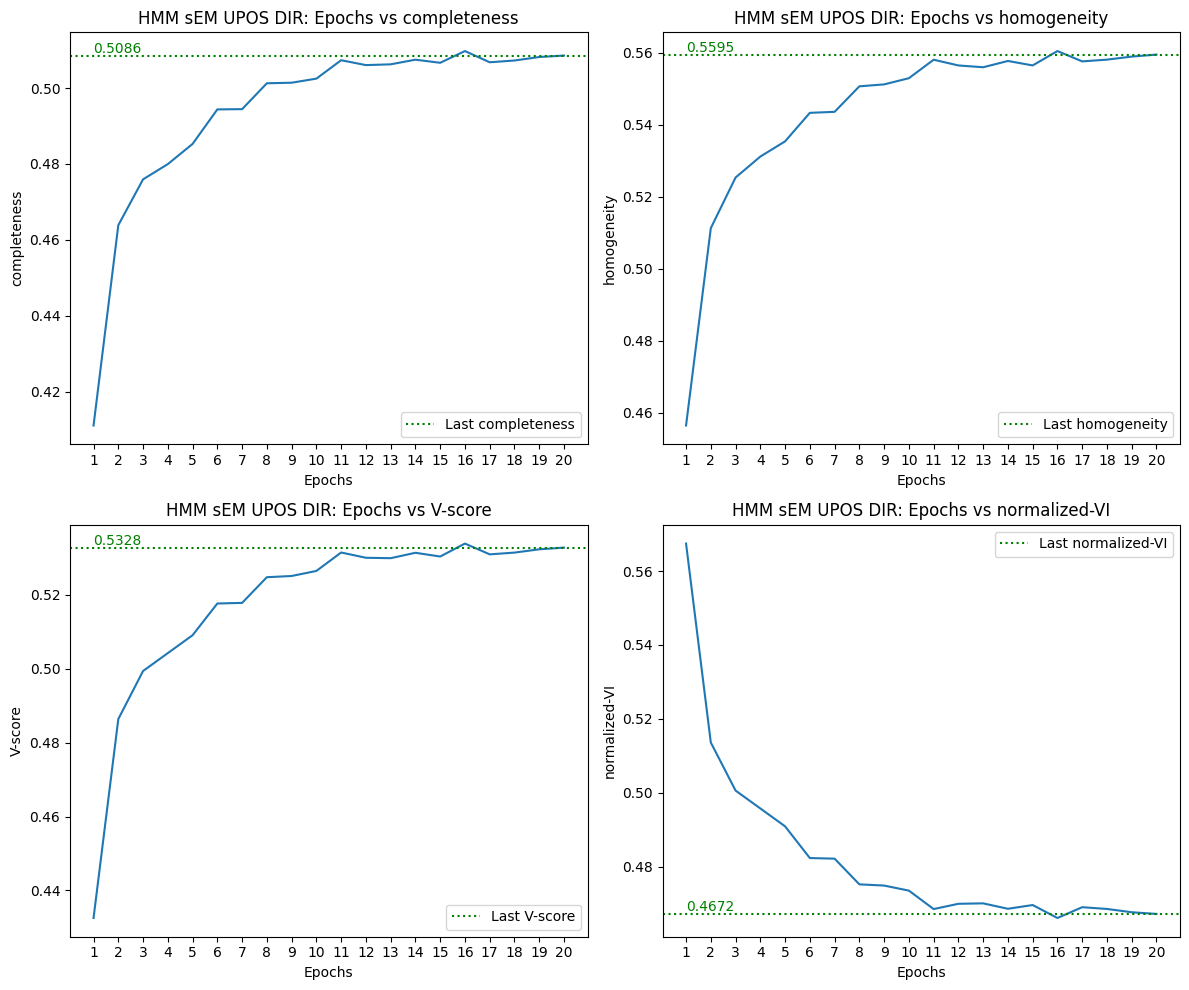

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

TAG = "upos"
FILE_PREFIX = f"hmm-sem-{TAG}-dir-alpha-0.6"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pd.read_csv(f"./output_old_sem_batch_size/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique())

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM sEM {TAG.upper()} Dirchilet: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## HMM Soft EM BOTH TAGS DIR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


TAG = "upos"
FILE_PREFIX = f"hmm-soft-em-{TAG}-dir"
NUM_STAGES = 100

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,6.881665,0.948317,0.053062,0.050375,0.051683,1
0,0,-,6.843361,0.938700,0.063225,0.059488,0.061300,2
0,0,-,6.785575,0.928761,0.073635,0.068993,0.071239,3
0,0,-,6.699806,0.913973,0.089218,0.083056,0.086027,4
0,0,-,6.602379,0.897280,0.106934,0.098825,0.102720,5


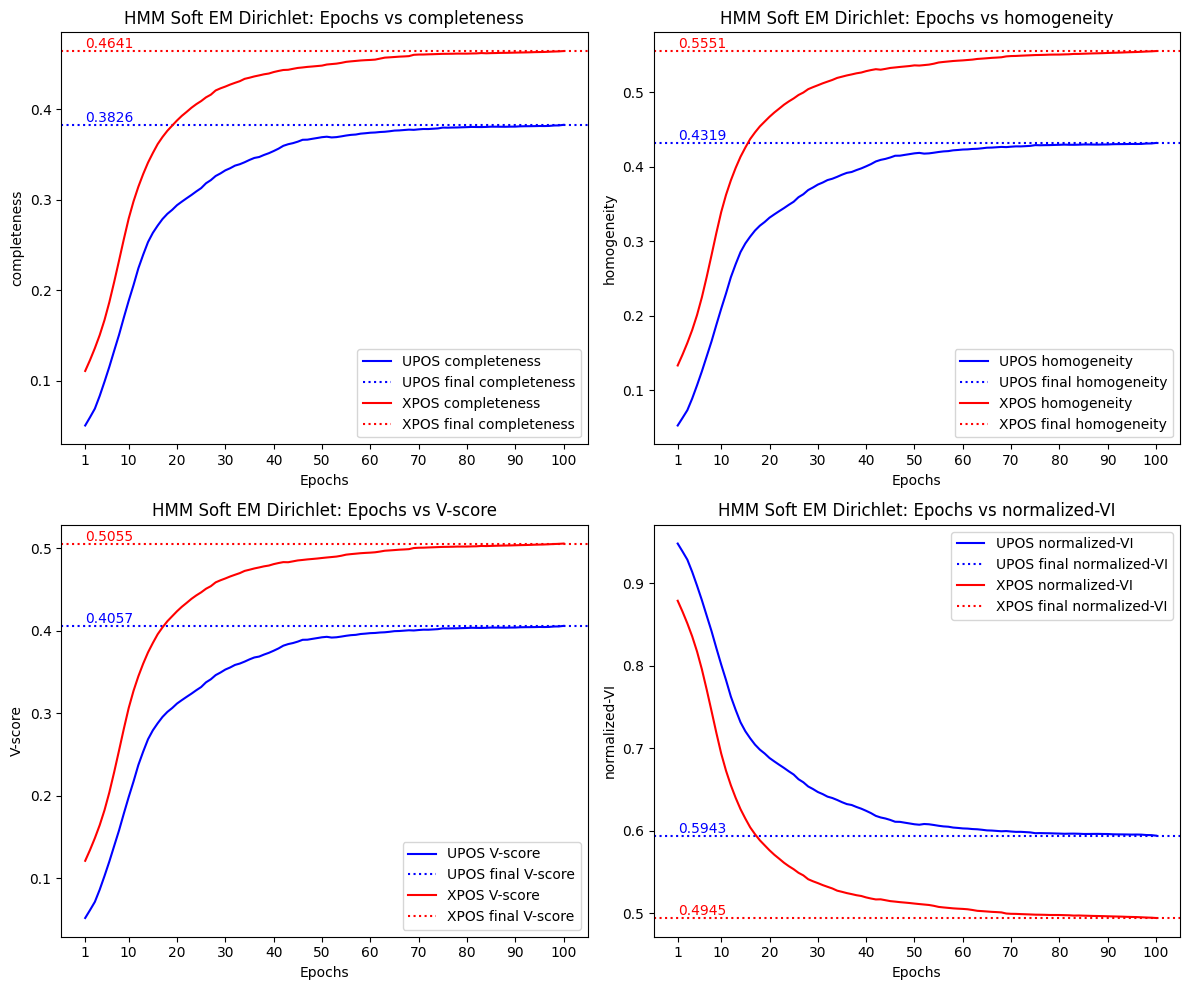

In [44]:
import pandas as pd
import matplotlib.pyplot as plt


FILE_PREFIXES = ["hmm-soft-em-upos-dir", "hmm-soft-em-xpos-dir"]
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]
NUM_STAGES = 100

LABELS = ["UPOS", "XPOS"]
COLORS = ["b", "r"]  # one color for each result type
FINAL_LINE_COLORS = ["b", "r"]

# Load both results
all_results = []
for FILE_PREFIX in FILE_PREFIXES:
    results = pd.read_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")
    all_results.append(results)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):
    ax = axes[i]
    for idx, results in enumerate(all_results):
        label = LABELS[idx]
        color = COLORS[idx]
        final_color = FINAL_LINE_COLORS[idx]

        epochs = results["epoch"]

        ax.plot(epochs, results[FIELD], label=f"{label} {FIELD}", color=color)

        # Add horizontal line for the last epoch's value
        last_value = results[FIELD].iloc[-1]
        ax.axhline(
            y=last_value,
            color=final_color,
            linestyle=':',
            label=f'{label} final {FIELD}'
        )
        
        # Add the value label near the left
        ax.text(
            epochs.min(), last_value, 
            f"{last_value:.4f}", 
            va='bottom', ha='left', color=final_color
        )
    
    ax.set_xticks([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

    ax.set_title(f"HMM Soft EM Dirichlet: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## HMM Soft EM PER TAG DIR

In [ ]:
import pandas
import matplotlib.pyplot as plt

TAG = "xpos"
FILE_PREFIX = f"hmm-soft-em-{TAG}-dir"
NUM_STAGES = 100

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,8.421723,0.878990,0.133547,0.110624,0.121010,1
0,0,-,8.295579,0.865790,0.148121,0.122688,0.134210,2
0,0,-,8.154861,0.851501,0.163815,0.135803,0.148499,3
0,0,-,8.001499,0.835785,0.181087,0.150219,0.164215,4
0,0,-,7.822995,0.817516,0.201140,0.166995,0.182484,5


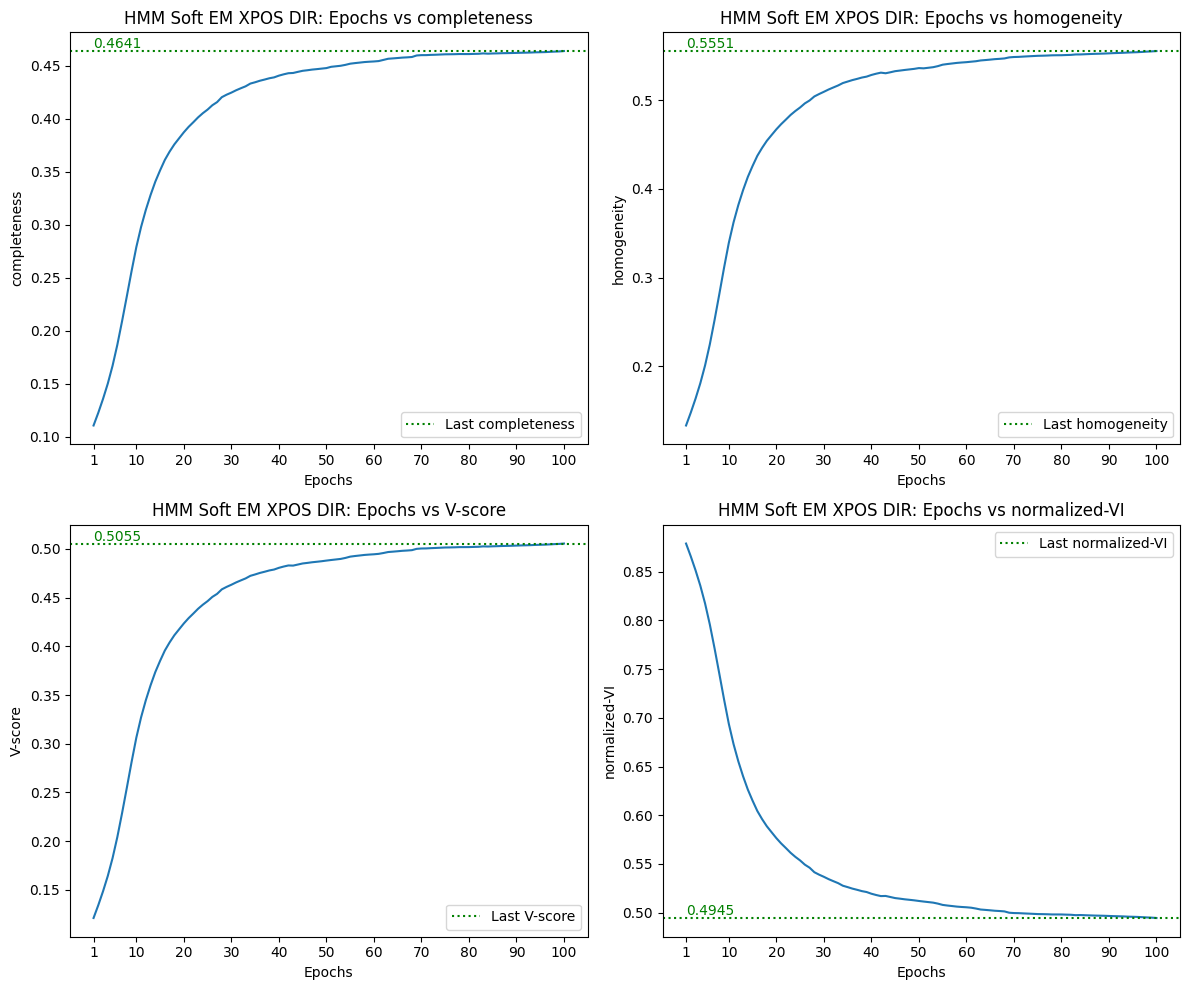

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

TAG = "xpos"
FILE_PREFIX = f"hmm-soft-em-{TAG}-dir"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pd.read_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique()[[0, 9, 19, 29, 39, 49, 59, 69, 79, 89, 99]])

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM Soft EM {TAG.upper()} Dirchilet: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## HMM Hard EM BOTH TAGS Random Init

In [ ]:
import pandas
import matplotlib.pyplot as plt


TAG = "upos"
FILE_PREFIX = f"hmm-hard-em-{TAG}-rand"
NUM_STAGES = 100

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 51 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,6.979666,0.952054,0.049730,0.046286,0.047946,1
0,0,-,6.956029,0.948958,0.052934,0.049281,0.051042,2
0,0,-,6.931340,0.945726,0.056277,0.052408,0.054274,3
0,0,-,6.910708,0.943095,0.058994,0.054959,0.056905,4
0,0,-,6.892532,0.940837,0.061321,0.057153,0.059163,5


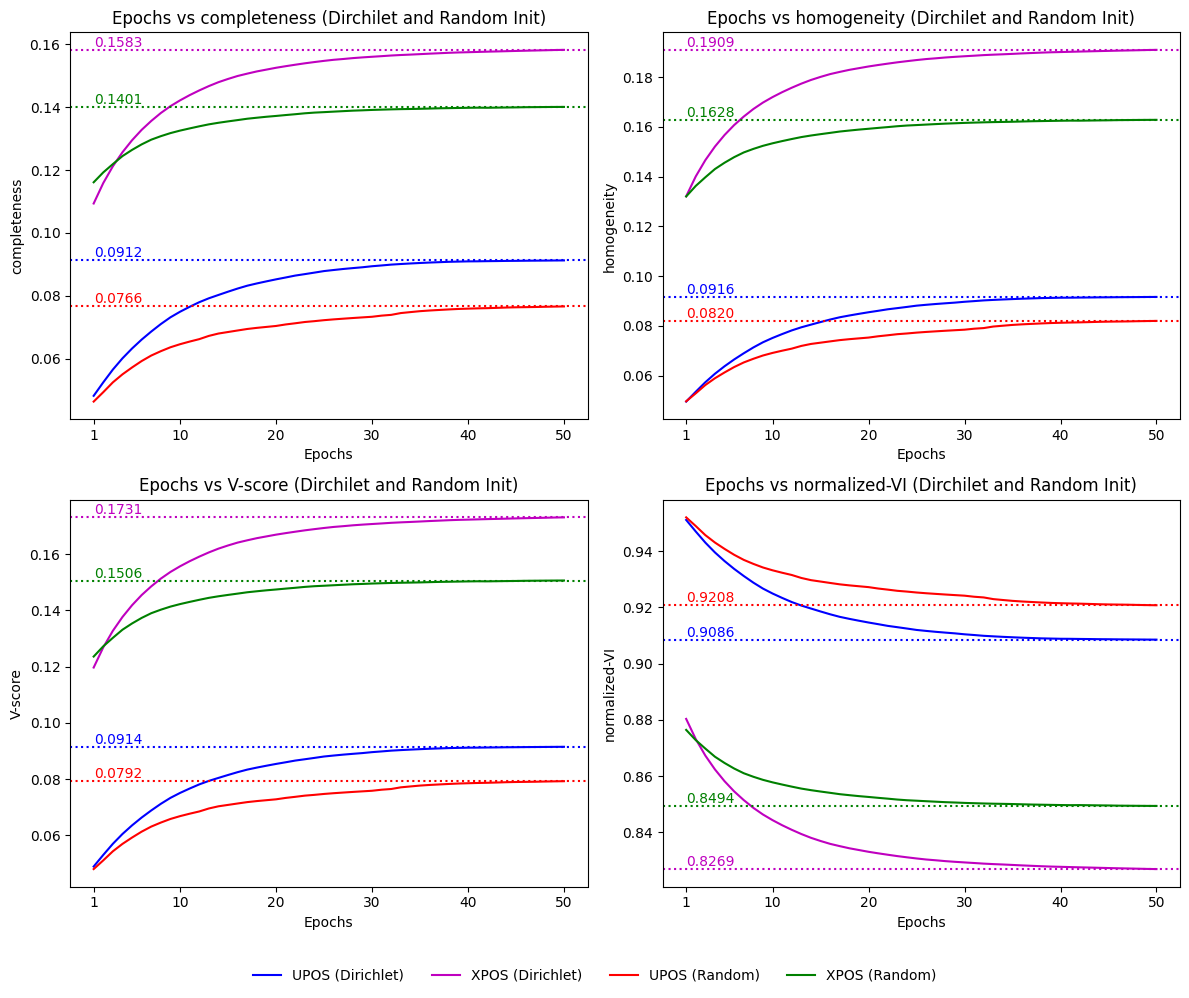

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


FILE_PREFIXES = ["hmm-hard-em-upos-dir", "hmm-hard-em-xpos-dir", "hmm-hard-em-upos-rand", "hmm-hard-em-xpos-rand"]
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]
LABELS = ["UPOS (Dirichlet)", "XPOS (Dirichlet)", "UPOS (Random)", "XPOS (Random)"]
COLORS = ["b", "m", "r", "g"]

# Load results
all_results = []
for FILE_PREFIX in FILE_PREFIXES:
    results = pd.read_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")
    all_results.append(results)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):
    ax = axes[i]
    for idx, results in enumerate(all_results):
        label = LABELS[idx]
        color = COLORS[idx]

        epochs = results["epoch"]

        if i == 0:
            ax.plot(epochs, results[FIELD], label=label, color=color)
        else:
            ax.plot(epochs, results[FIELD], color=color)

        # Add last value
        last_value = results[FIELD].iloc[-1]
        ax.axhline(
            y=last_value,
            color=color,
            linestyle=':',
            label='_nolegend_' 
        )
        
        # Add the value label near the left
        ax.text(
            epochs.min(), last_value, 
            f"{last_value:.4f}", 
            va='bottom', ha='left', color=color
        )
    
    ax.set_xticks([1, 10, 20, 30, 40, 50])
    ax.set_title(f"Epochs vs {FIELD} (Dirchilet and Random Init)")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")

# Bottom legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0), ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()

## HMM Hard EM SINGLE TAG Random init

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

TAG = "xpos"
FILE_PREFIX = f"hmm-hard-em-{TAG}-rand"
NUM_STAGES = 100

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pd.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pd.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 51 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,8.129751,0.876451,0.132004,0.116112,0.123549,1
0,0,-,8.117026,0.872810,0.136247,0.119262,0.127190,2
0,0,-,8.103056,0.869795,0.139720,0.121904,0.130205,3
0,0,-,8.087844,0.866905,0.143027,0.124452,0.133095,4
0,0,-,8.074782,0.864679,0.145559,0.126429,0.135321,5


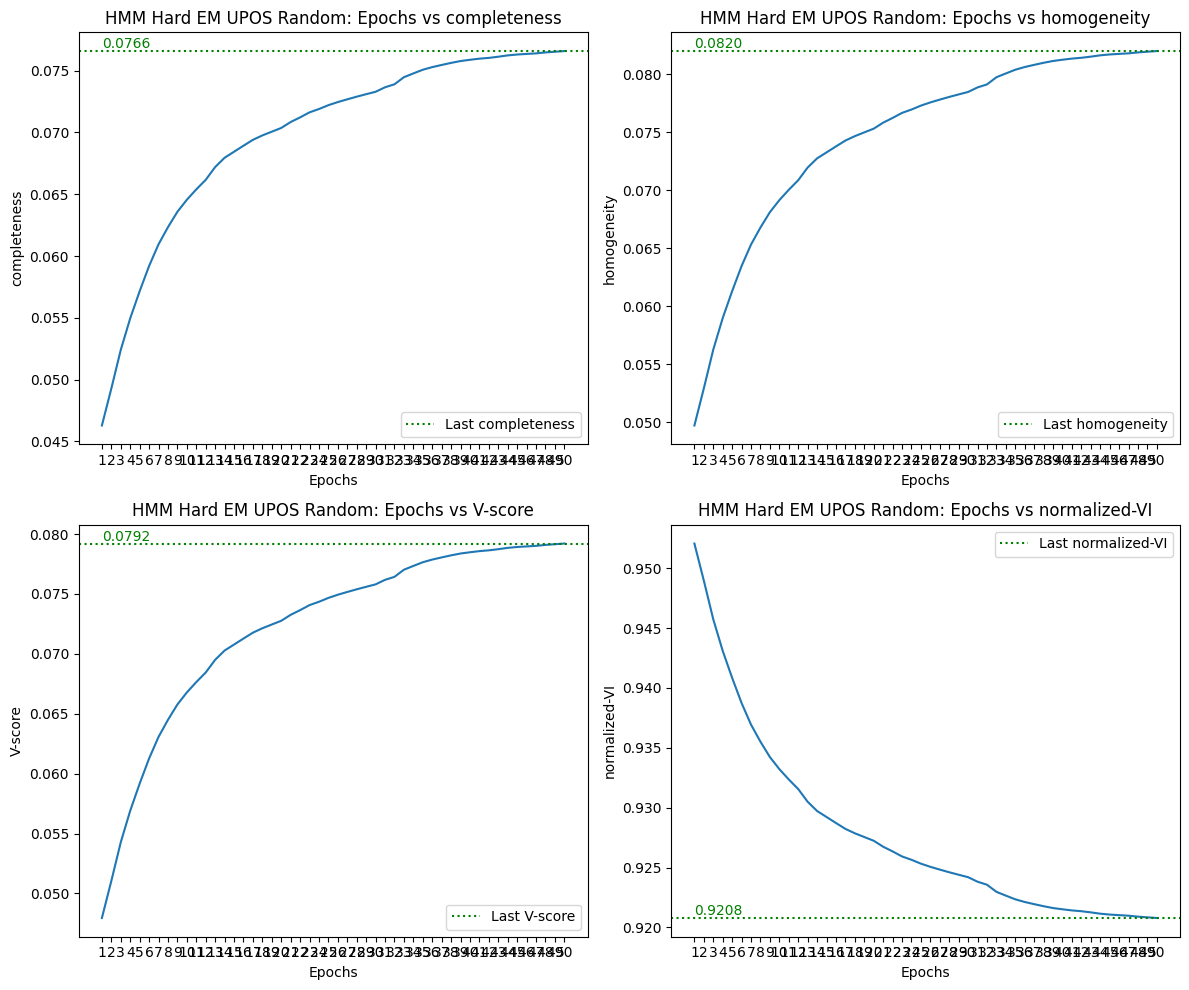

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

TAG = "upos"
FILE_PREFIX = f"hmm-hard-em-{TAG}-rand"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pd.read_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique())

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM Hard EM {TAG.upper()} Random: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## HMM sem dir upos single alpha

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

ALPHA = 1.0
TAG = "xpos"
FILE_PREFIX = f"hmm-sem-{TAG}-dir-alpha-{ALPHA}"
NUM_STAGES = 100

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}.{i}.csv"
    try:
        df = pd.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pd.concat(all_results)
all_results.to_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 21 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,0,-,6.890423,0.732463,0.289896,0.248381,0.267537,1
0,0,-,6.645332,0.706171,0.318493,0.272711,0.293829,2
0,0,-,6.516678,0.692053,0.334010,0.285656,0.307947,3
0,0,-,6.431280,0.682565,0.344513,0.294304,0.317435,4
0,0,-,6.371138,0.675912,0.351874,0.300369,0.324088,5


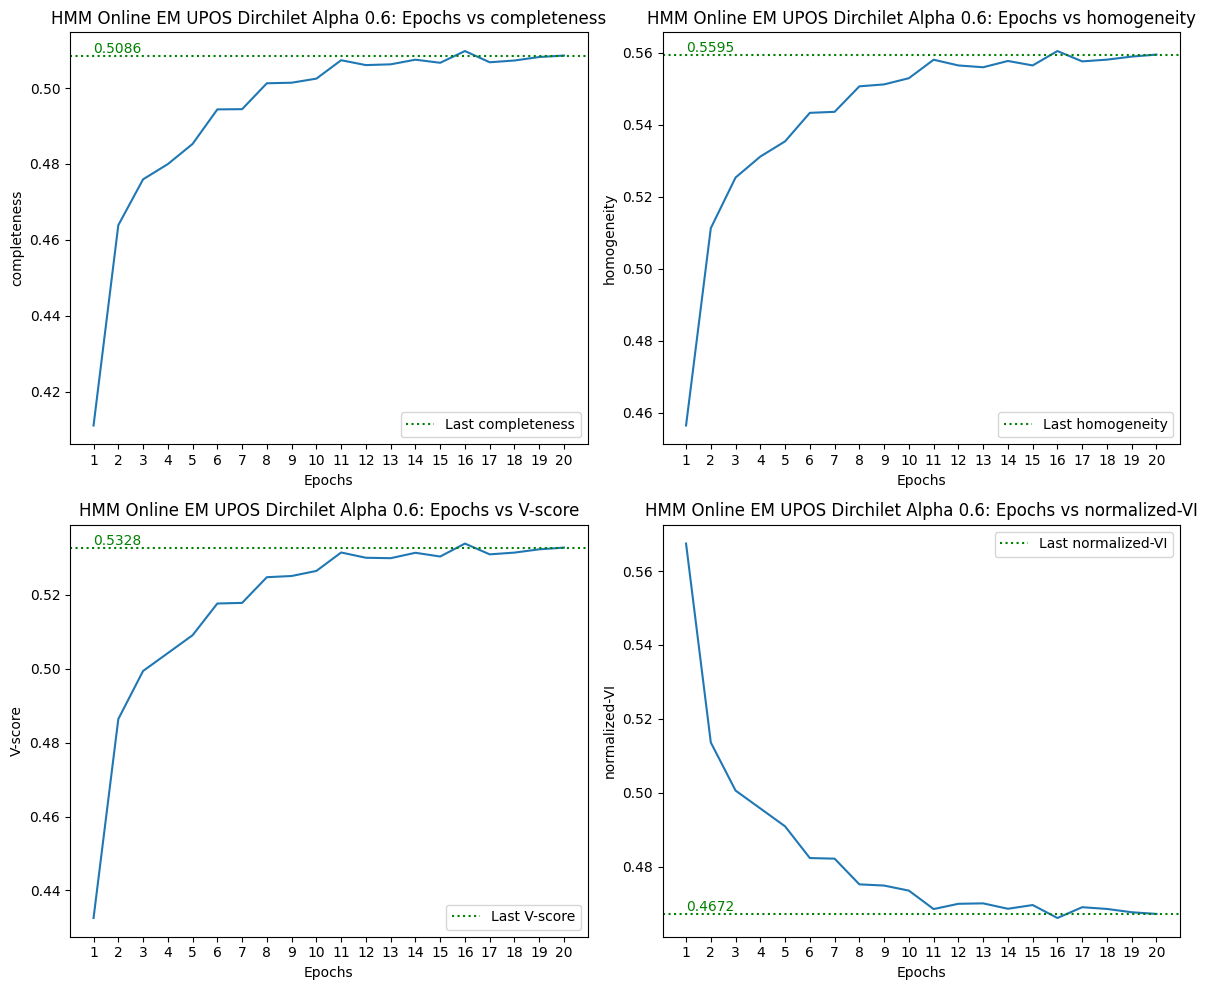

In [61]:
import pandas
import matplotlib.pyplot as plt

ALPHA = 0.6
TAG = "upos"
FILE_PREFIX = f"hmm-sem-{TAG}-dir-alpha-{ALPHA}"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pandas.read_csv(f"./output_old_sem_batch_size/{FILE_PREFIX}/results/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique())

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM Online EM {TAG.upper()} Dirchilet Alpha {ALPHA}: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## All Alphas final value graph sEM

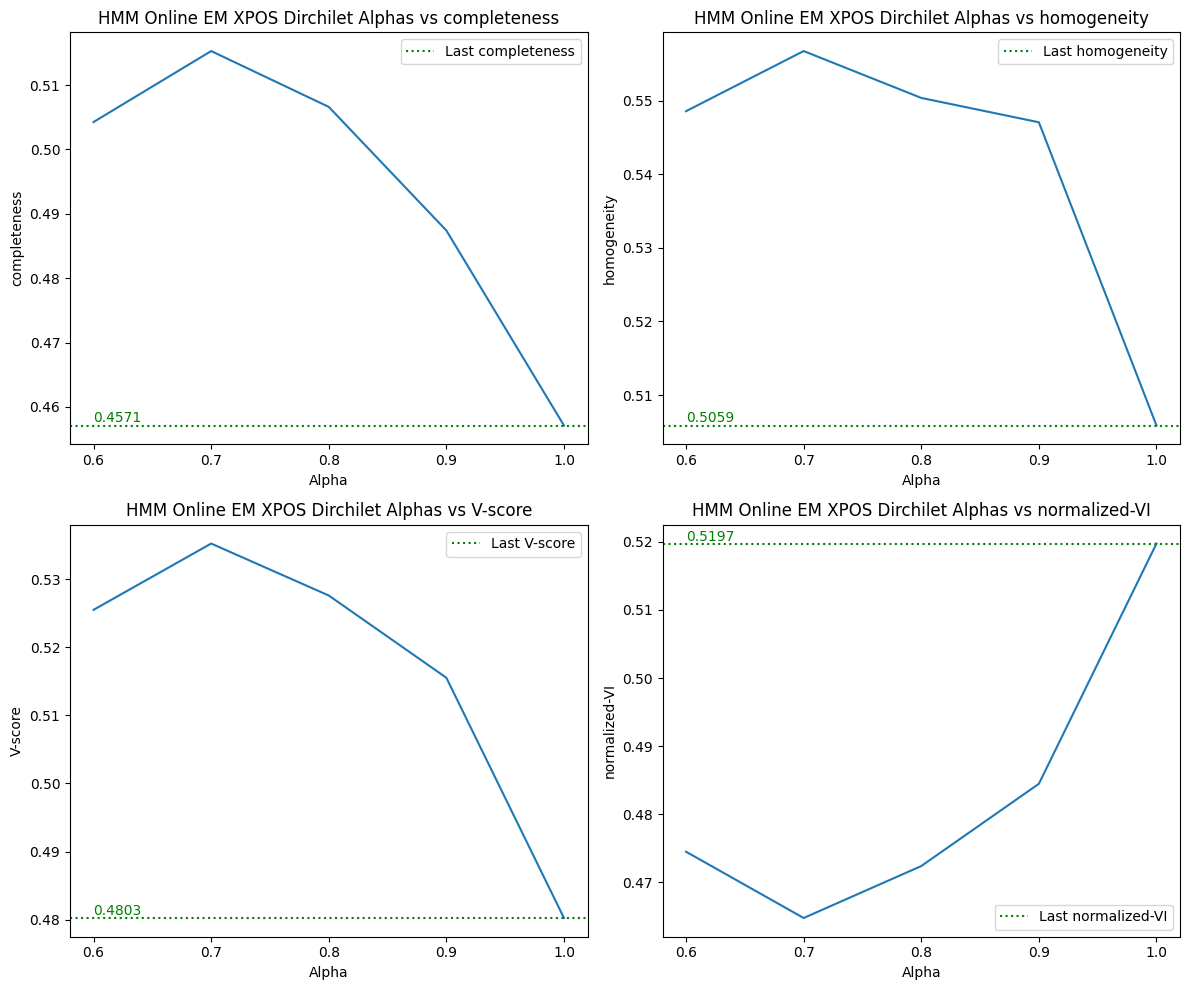

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]
TAG = "xpos"
ALPHAS = [0.6, 0.7, 0.8, 0.9, 1.0]

all_results = pd.read_csv(f"./output_old_sem_batch_size/hmm-sem-{TAG}-dir-alpha-all/results.csv")

all_results = all_results[all_results["alpha"].isin(ALPHAS)]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["alpha"], all_results[FIELD])
    ax.set_xticks(ALPHAS)

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["alpha"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM Online EM {TAG.upper()} Dirchilet Alphas vs {FIELD}")
    ax.set_xlabel("Alpha")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

## Rand and Dirchilet on 1 graph

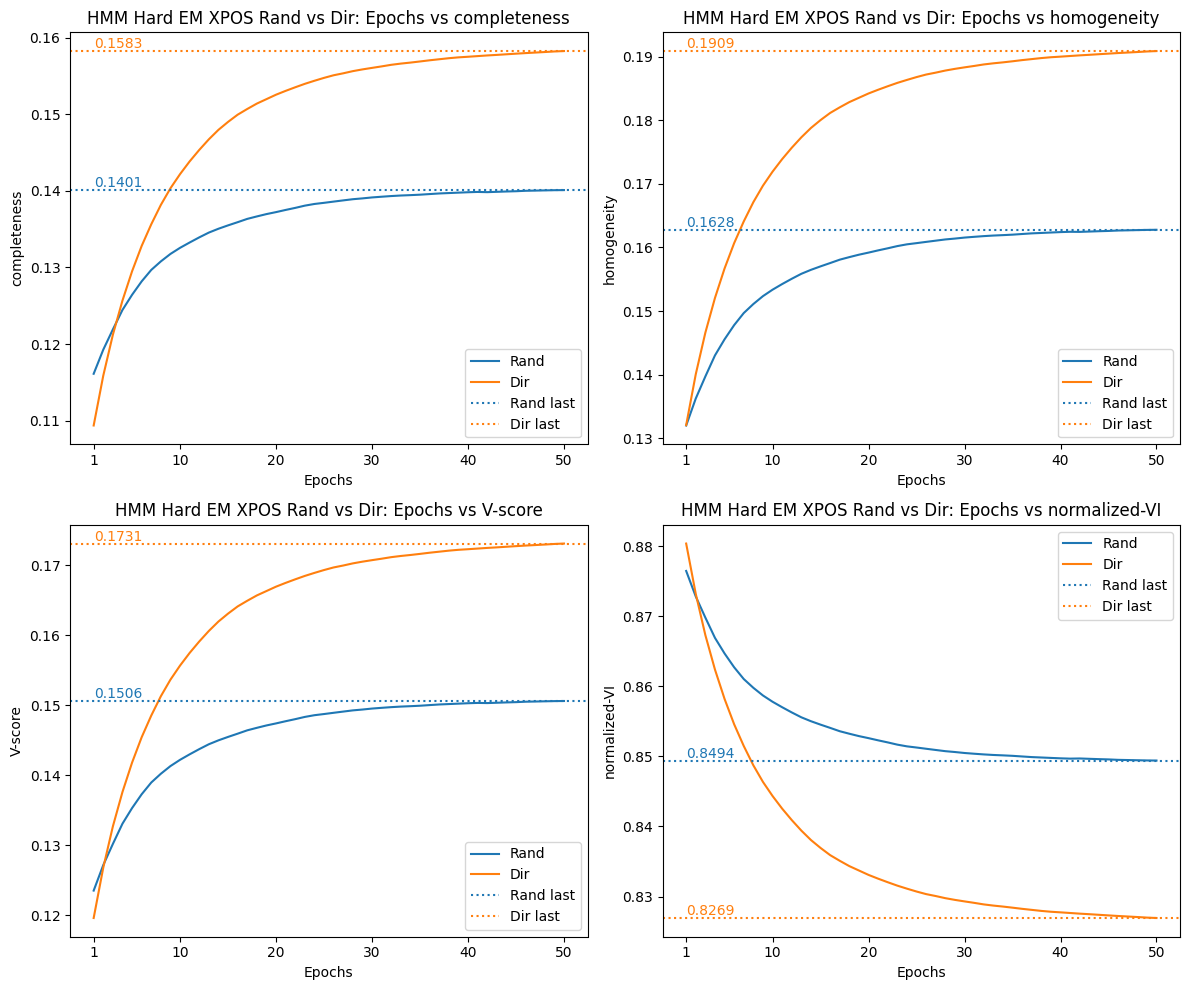

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

tag = 'xpos'
rand_results = pd.read_csv(f"./output/hmm-hard-em-{tag}-rand/results/hmm-hard-em-{tag}-rand-all-stages.csv")
dir_results = pd.read_csv(f"./output/hmm-hard-em-{tag}-dir/results/hmm-hard-em-{tag}-dir-all-stages.csv")

FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):
    ax = axes[i]

    rand_last = rand_results[FIELD].iloc[-1]
    dir_last = dir_results[FIELD].iloc[-1]

    ax.plot(rand_results["epoch"], rand_results[FIELD], label="Rand", color="C0")
    ax.plot(dir_results["epoch"], dir_results[FIELD], label="Dir", color="C1")

    ax.set_xticks(rand_results["epoch"].iloc[[0, 9, 19, 29, 39, 49]])

    ax.axhline(y=rand_last, color="C0", linestyle=":", label="Rand last")
    ax.axhline(y=dir_last, color="C1", linestyle=":", label="Dir last")

    ax.text(rand_results["epoch"].min(), rand_last, f"{rand_last:.4f}", va="bottom", ha="left", color="C0")
    ax.text(rand_results["epoch"].min(), dir_last, f"{dir_last:.4f}", va="bottom", ha="left", color="C1")

    ax.set_title(f"HMM Hard EM {tag.upper()} Rand vs Dir: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(FIELD)
    ax.legend()

plt.tight_layout()
plt.show()

## All alphas on 1 graph

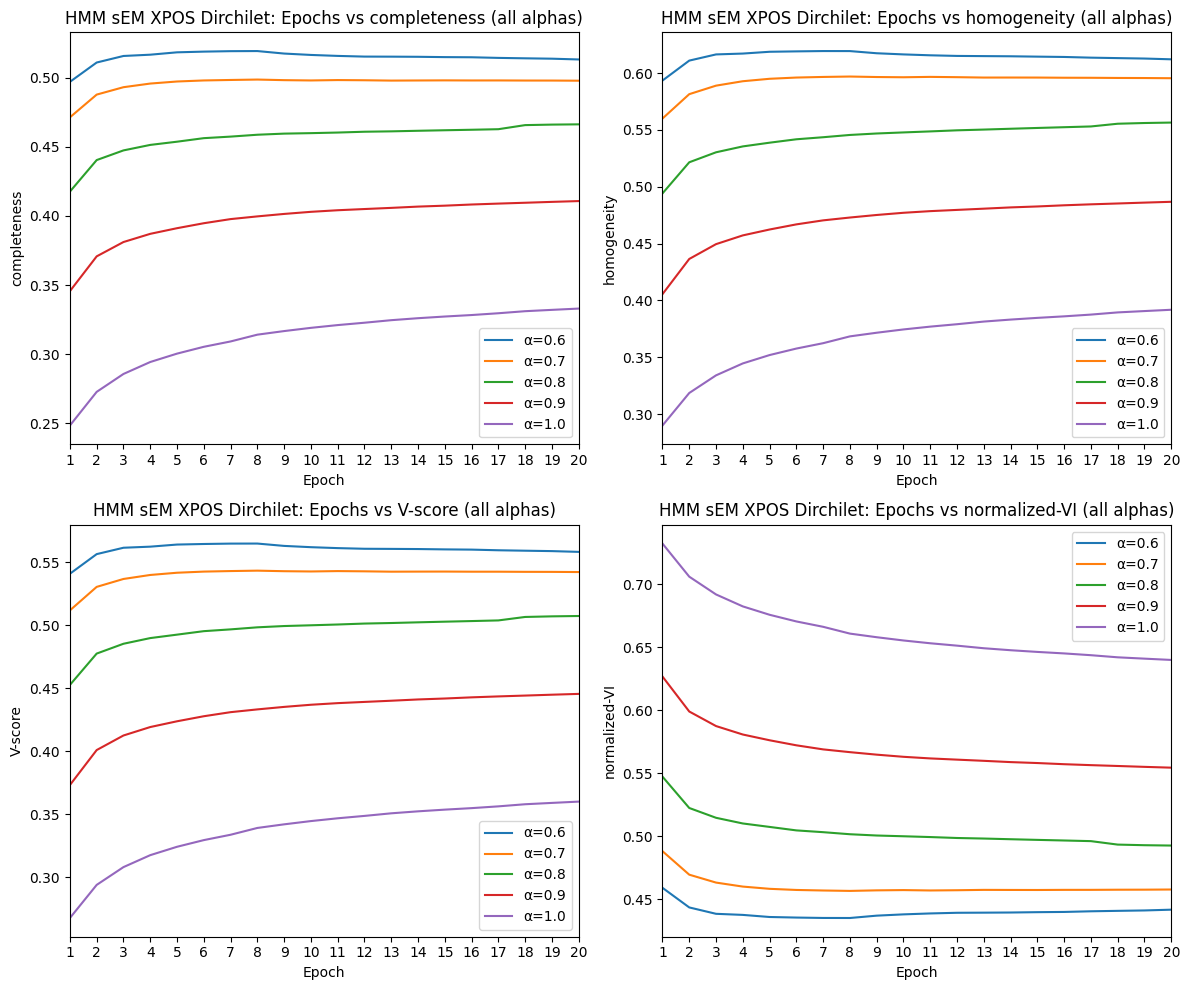

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


EPOCHS = list(range(1, 21))
ALPHAS = [0.6, 0.7, 0.8, 0.9, 1.0]
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]
TAG = "xpos"

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):
    ax = axes[i]
    for alpha in ALPHAS:
        # path = f"./output_old_sem_batch_size/hmm-sem-{TAG}-dir-alpha-{alpha}/results/hmm-sem-{TAG}-dir-alpha-{alpha}-all-stages.csv"
        path = f"./output/hmm-sem-{TAG}-dir-alpha-{alpha}/results/hmm-sem-{TAG}-dir-alpha-{alpha}-all-stages.csv"
        df = pd.read_csv(path)
        ax.plot(EPOCHS, df[FIELD].iloc[0:20], label=f"α={alpha}")
    ax.set_xticks(EPOCHS)
    ax.set_xlim(EPOCHS[0], EPOCHS[-1])
    ax.set_title(f"HMM sEM {TAG.upper()} Dirchilet: Epochs vs {FIELD} (all alphas)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(FIELD)
    ax.legend()

plt.tight_layout()
plt.show()

## All results of all models on 1 graph to show relative performance

- hmm-hard-em-upos-dir
- hmm-sem-upos-dir
- hmm-soft-em-upos-dir
- nhmm-upos
- kmeans-upos


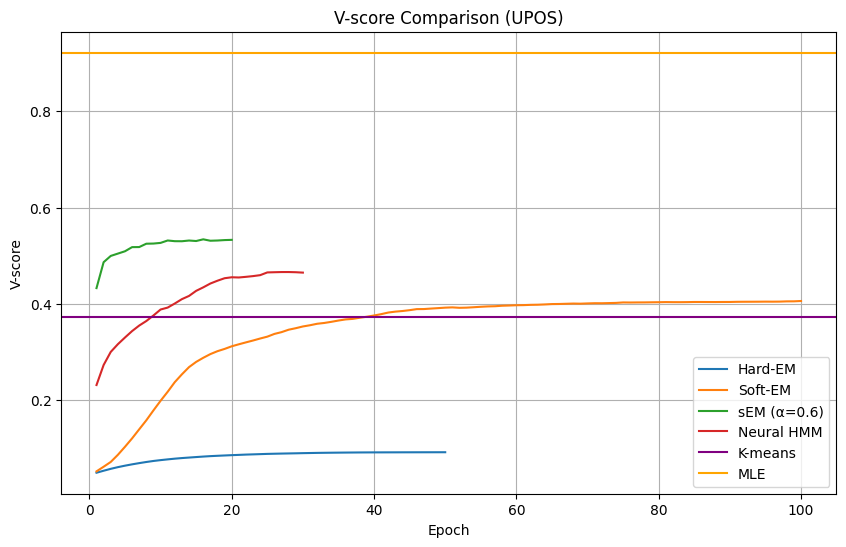

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

TAG = "upos"

hard_em = pd.read_csv(f"./output/hmm-hard-em-{TAG}-dir/results/hmm-hard-em-{TAG}-dir-all-stages.csv")
soft_em = pd.read_csv(f"./output/hmm-soft-em-{TAG}-dir/results/hmm-soft-em-{TAG}-dir-all-stages.csv")
sem = pd.read_csv(f"./output_old_sem_batch_size/hmm-sem-{TAG}-dir-alpha-0.6/results/hmm-sem-{TAG}-dir-alpha-0.6-all-stages.csv")
nhmm = pd.read_csv(f"./output/nhmm-{TAG}/results/nhmm-{TAG}-results.csv")
kmeans = pd.read_csv(f"./output/kmeans-{TAG}/results/kmeans-{TAG}.csv").iloc[0]
mle = pd.read_csv(f"./output/hmm-mle-{TAG}/hmm-mle-{TAG}.csv").iloc[0]

plt.figure(figsize=(10, 6))

plt.plot(hard_em["epoch"], hard_em["V-score"], label="Hard-EM")
plt.plot(soft_em["epoch"], soft_em["V-score"], label="Soft-EM")
plt.plot(sem["epoch"], sem["V-score"], label="sEM (α=0.6)")
plt.plot(nhmm["epoch"], nhmm["V-score"], label="Neural HMM")

plt.axhline(y=kmeans["V-score"], linestyle="-", color="purple", label=f"K-means")

plt.axhline(y=mle["V-score"], linestyle="-", color="orange", label=f"MLE")

plt.xlabel("Epoch")
plt.ylabel("V-score")
plt.title(f"V-score Comparison ({TAG.upper()})")

plt.legend()

plt.grid(True)

plt.show()

## Kmeans extraction of worst 5 sentences

In [ ]:
import pandas as pd

# Load kmeans results (skip row 0 which is overall stats)
df = pd.read_csv("./output/kmeans-upos/results/kmeans-upos.csv")
df = df[df["id"] != 0]

# Worst by V-score (lowest = worst)
print("=== Worst 10 sentences by V-score ===")
worst_vscore = df.nsmallest(10, "V-score")[["id", "sentence", "V-score", "normalized-VI"]]
print(worst_vscore.to_string())

# Worst by normalized-VI (highest = worst)
print("\n=== Worst 10 sentences by normalized-VI ===")
worst_vi = df.nlargest(10, "normalized-VI")[["id", "sentence", "V-score", "normalized-VI"]]
print(worst_vi.to_string())

=== Worst 10 sentences by V-score ===
        id                        sentence  V-score  normalized-VI
201    201                       Perhaps .      0.0            1.0
668    668                  Public Affairs      0.0            1.0
1008  1008                William S. Smith      0.0            1.0
1014  1014          Virginia M.W. Gardiner      0.0            1.0
1069  1069  Okobank -LRB- Finland -RRB- --      0.0            1.0
1913  1913                     He ca n't .      0.0            1.0
2262  2262              -- Marvin Alisky .      0.0            1.0
3495  3495             Treasury Securities      0.0            1.0
3517  3517                Corporate Issues      0.0            1.0
3546  3546                Municipal Issues      0.0            1.0

=== Worst 10 sentences by normalized-VI ===
        id                        sentence  V-score  normalized-VI
201    201                       Perhaps .      0.0            1.0
668    668                  Public Affairs    

## NHMM Epochs Graphs

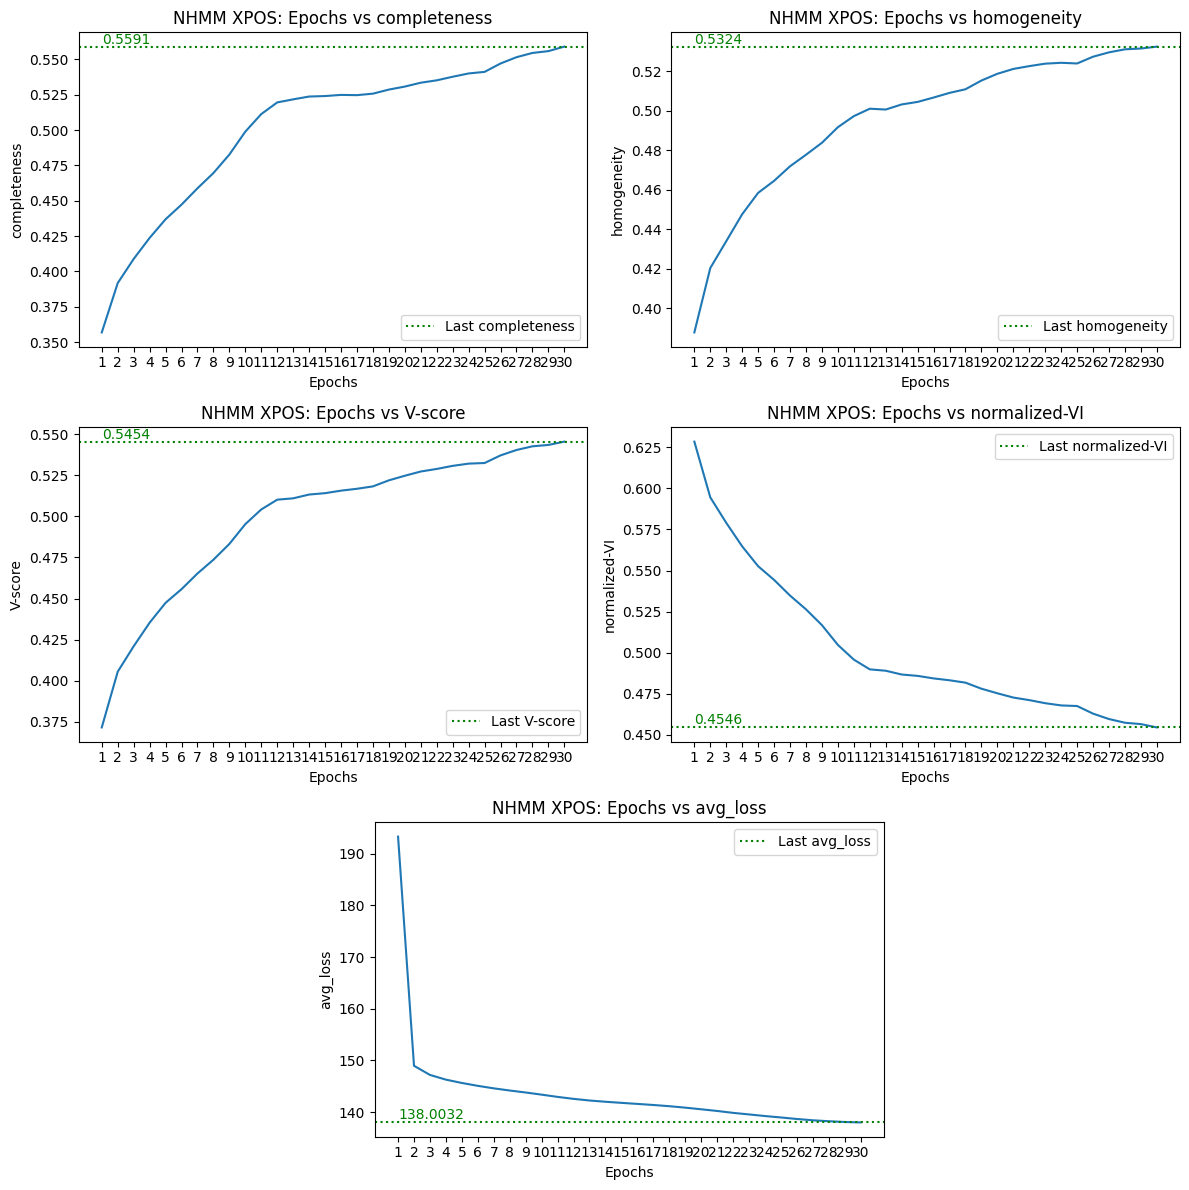

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

TAG = "xpos"
FILE_PREFIX = f"nhmm-{TAG}"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI", "avg_loss"]

# Load your data
all_results = pd.read_csv(f"./output/{FILE_PREFIX}/results/{FILE_PREFIX}-results.csv")

# Create figure with extra height for the legend/titles
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):
    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique())

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"NHMM {TAG.upper()}: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

# 1. Hide the empty 6th plot
axes[5].set_visible(False)

# 2. Run tight_layout FIRST to fix spacing for the top 4 graphs
plt.tight_layout()

# 3. Manually center the 5th graph (index 4)
# Get the positions of the left (4) and right (5) slots in the bottom row
box_4 = axes[4].get_position()
box_5 = axes[5].get_position()

# Calculate the center of the entire row
# (Start of left box + End of right box) / 2
row_center_x = (box_4.x0 + box_5.x1) / 2
new_left_x = row_center_x - (box_4.width / 2)

# Move the 5th graph to the new calculated position
axes[4].set_position([new_left_x, box_4.y0, box_4.width, box_4.height])

plt.show()